In [36]:
import os, sys
sys.path.append('C:\\_Lib\\python\\slab\\instruments')
sys.path.append('C:\\_Lib\\python') 
# sys.path.append('C:\\Users\\slab.DESKTOP-JFLC5N4\\Documents\\Junction_IV\\Instrument_Ctrl')

import RhodeSchwarz
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time
import pickle
import fitres
from mpl_toolkits.axes_grid1.inset_locator import inset_axes



In [40]:
RS = RhodeSchwarz.ZVB8(address='192.168.137.84')
RS.get_id()

I'm Bat Mouse!


'Rohde-Schwarz,ZNB26-4Port,1334333065100972,3.45\n'

In [ ]:
b = Basel(allowed_range_mv=15000)
CH = 1  ## Basal channel

VOLTAGE_MV = 50

b.set_voltage_mV(CH, voltage_mv=VOLTAGE_MV)
b.enable_output(CH)

In [68]:
settings

{'channel': 1,
 'avg_time': 5,
 'measurement': 'S21',
 'start_freq': 1000000000.0,
 'stop_freq': 11000000000.0,
 'freq_points': 10001,
 'RFpower': -60,
 'ifBW': 10000,
 'mode': 'MOV'}

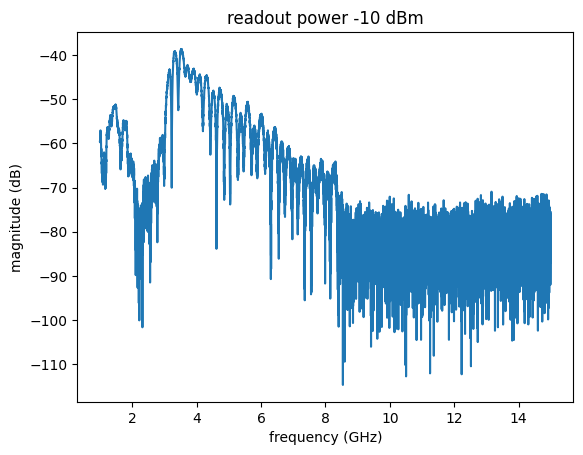

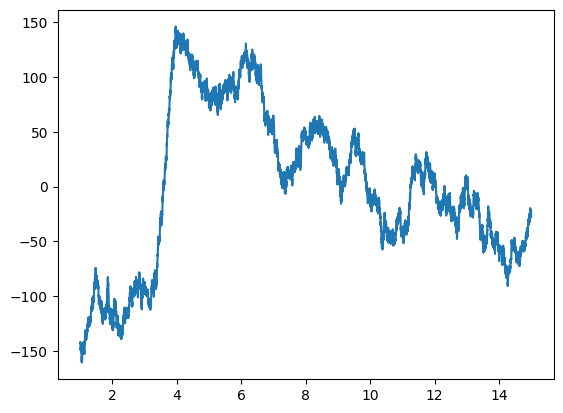

In [134]:
num_freqs = 10001

start = 1; stop = 15; step = 14
#start = 7.6; stop = 7.8; step = 0.2

current = start
freq_all = np.array([])
mag_all = np.array([])
phase_all = np.array([]) 


while current < stop:
        
    # RS.reset()
    settings = RS.trans_default_settings()
    settings['measurement'] = 'S43'
    settings['start_freq'] = (current)*1e9
    settings['stop_freq'] = (current + step)*1e9
    settings['RFpower'] = -10
    settings['ifBW'] = 10000
    settings['avg_time'] = 5
    # if RFpower < -30:
    #     settings['avg_time'] = 0.5 * (10 ** (-RFpower/10)) / (10 ** (30/10))  # Increase averaging time for lower powers

    settings['freq_points'] = num_freqs
    data2 = RS.trans_meas(settings)
    mag = np.array(eval(str(data2['mag'])))
    phase = np.array(eval(str(data2['phase'])))
    freq = np.array(eval(str(data2['xaxis'])))/1e9

    freq_all = np.concatenate((freq_all,freq))
    mag_all = np.concatenate((mag_all,mag))
    phase_all = np.concatenate((phase_all,phase))

    phase_all_plot = np.unwrap(phase_all)
    phase_fit = np.polyfit(freq_all, phase_all_plot, 1)
    phase_all_plot = phase_all_plot - np.polyval(phase_fit, freq_all)

    current += step


    clear_output(wait=True)  # clears previous plot in the notebook cell
    print(f'Measured {current-start:.2f} GHz / {stop-start:.2f} GHz', end='\r')
    plt.plot(freq_all, mag_all)
    plt.xlabel('frequency (GHz)')
    plt.ylabel('magnitude (dB)')
    plt.title('readout power {} dBm'.format(settings['RFpower']))

    plt.figure()
    plt.plot(freq_all, phase_all_plot)
    
    plt.show()
    time.sleep(0.1)   
    # res_idx = np.argmin(abs(freq-6.9028))
    # plt.plot(freq_all,mag_all)
    # plt.plot(freq[res_idx],mag[res_idx],'ro')
    # plt.show()
pickle.dump((freq_all, mag_all, phase_all), open('C:/_Data/SMPD/2026_02_06/A11-C7.pkl', 'wb'))

C10_circulator_to_output.pkl
C11_circulator_to_output.pkl
C5_circulator_to_output.pkl
C6_circulator_to_output.pkl
C7_circulator_to_output.pkl
C9_circulator_to_output.pkl


(-100.0, 46.2460797998)

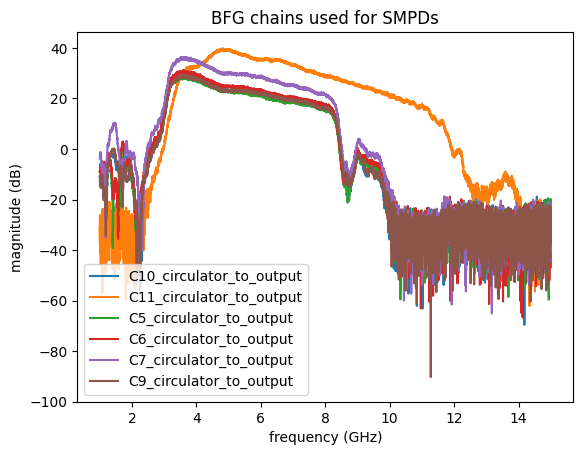

In [141]:
data_dir = 'C:/_Data/SMPD/2026_02_06/circulator_input_port'
for file in os.listdir(data_dir):
    if file.endswith('.pkl') :
        print(file)
        freq_all, mag_all, phase_all = pickle.load(open(os.path.join(data_dir, file), 'rb'))
        plt.plot(freq_all, mag_all,label=file.split('/')[-1].split('.')[0])
        
plt.xlabel('frequency (GHz)')
plt.ylabel('magnitude (dB)')
plt.title('BFG chains used for SMPDs')
plt.legend()
plt.ylim(bottom=-100)

C10_circulator_to_output.pkl
C11_circulator_to_output.pkl
C5_circulator_to_output.pkl
C6_circulator_to_output.pkl
C8_circulator_to_output.pkl
C9_circulator_to_output.pkl


(-100.0, 54.80822177935)

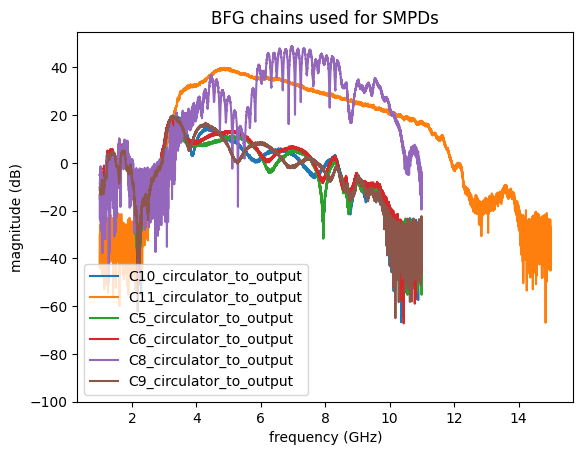

In [140]:
data_dir = 'C:/_Data/SMPD/2026_02_06/circulator_reflection_port'
for file in os.listdir(data_dir):
    if file.endswith('.pkl') :
        print(file)
        freq_all, mag_all, phase_all = pickle.load(open(os.path.join(data_dir, file), 'rb'))
        plt.plot(freq_all, mag_all,label=file.split('/')[-1].split('.')[0])
        
plt.xlabel('frequency (GHz)')
plt.ylabel('magnitude (dB)')
plt.title('BFG chains used for SMPDs')
plt.legend()
plt.ylim(bottom=-100)

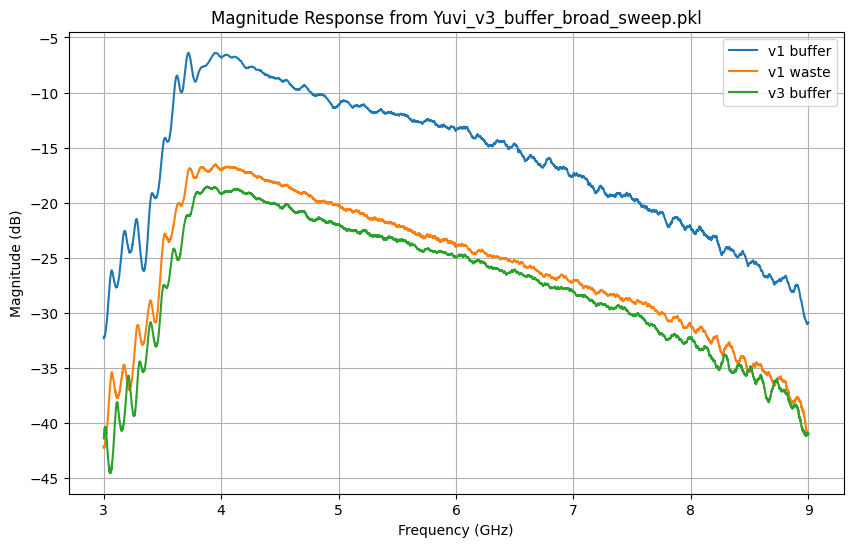

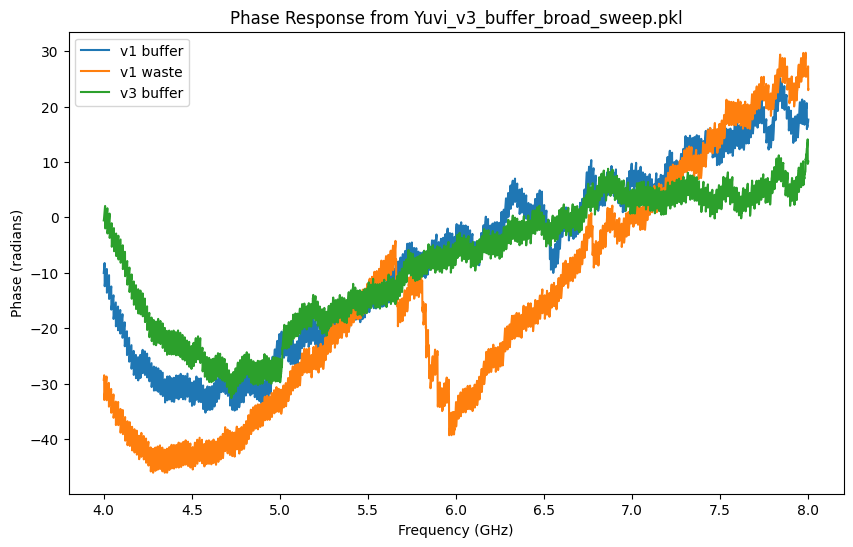

In [34]:
data_dir = 'C:/_Data/SMPD/2026_01_16/'
fig1,ax1 = plt.subplots(figsize=(10,6), num=1)
fig2,ax2 = plt.subplots(figsize=(10,6), num=2)
for file in os.listdir(data_dir):
    if file.endswith('.pkl') and not 'v3_waste' in file:
        file_id = file.split('_')[1] +' ' + file.split('_')[2]
        freq_all, mag_all, phase_all = pickle.load(open(os.path.join(data_dir, file), 'rb'))
        # plt.figure(num=1)
        ax1.plot(freq_all, mag_all,label=file_id)
        ax1.set_xlabel('Frequency (GHz)')
        ax1.set_ylabel('Magnitude (dB)')
        ax1.set_title(f'Magnitude Response from {file}')
        ax1.legend()
        ax1.grid(True)
    
        # plt.figure(num=2)
        phase_all_plot = np.unwrap(phase_all)
        phase_fit = np.polyfit(freq_all, phase_all_plot, 1)
        phase_all_plot = phase_all_plot - np.polyval(phase_fit, freq_all)
        freq_conditional = (freq_all>4)&(freq_all<8)
        ax2.plot(freq_all[freq_conditional], phase_all_plot[freq_conditional],label=file_id)
        ax2.set_xlabel('Frequency (GHz)')
        ax2.set_ylabel('Phase (radians)')
        ax2.set_title(f'Phase Response from {file}')
        ax2.legend()
        # plt.tight_layout()
        # plt.show()

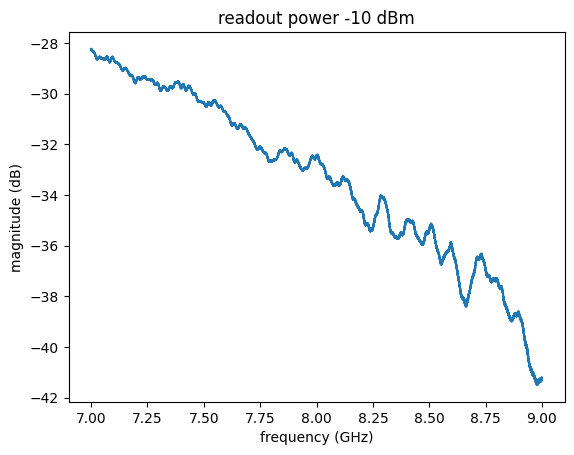

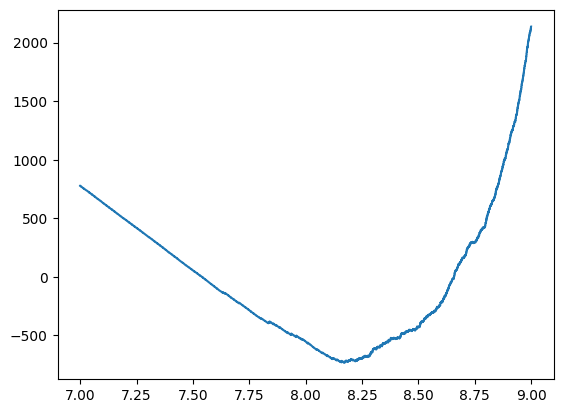

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 10001 and the array at index 1 has size 20002

In [ ]:
num_freqs = 10001
num_dc_powers = 3

freq_array = np.zeros((num_dc_powers, num_freqs))
mag_array = np.array((num_dc_powers, num_freqs))
phase_array = np.array((num_dc_powers, num_freqs))


for i, dc_power in enumerate(np.linspace(0,50,num_dc_powers)):
    b.set_voltage_mV(CH,dc_power)
    b.enable_output(CH)
    time.sleep(0.1)
    start = 7; stop = 9; step = 1
    #start = 7.6; stop = 7.8; step = 0.2

    current = start
    freq_all = np.array([])
    mag_all = np.array([])
    phase_all = np.array([]) 


    while current < stop:
            
        RS.reset()
        settings = RS.trans_default_settings()
        settings['measurement'] = 'S43'
        settings['start_freq'] = (current)*1e9
        settings['stop_freq'] = (current + step)*1e9
        settings['RFpower'] = -10
        settings['ifBW'] = 10000
        settings['avg_time'] = 10
        # if RFpower < -30:
        #     settings['avg_time'] = 0.5 * (10 ** (-RFpower/10)) / (10 ** (30/10))  # Increase averaging time for lower powers

        settings['freq_points'] = num_freqs
        data2 = RS.trans_meas(settings)
        mag = np.array(eval(str(data2['mag'])))
        phase = np.array(eval(str(data2['phase'])))
        freq = np.array(eval(str(data2['xaxis'])))/1e9

        freq_all = np.concatenate((freq_all,freq))
        mag_all = np.concatenate((mag_all,mag))
        phase_all = np.concatenate((phase_all,phase))

        phase_all_plot = np.unwrap(phase_all)
        phase_fit = np.polyfit(freq_all, phase_all_plot, 1)
        phase_all_plot = phase_all_plot - np.polyval(phase_fit, freq_all)

        current += step


        clear_output(wait=True)  # clears previous plot in the notebook cell
        print(f'Measured {current-start:.2f} GHz / {stop-start:.2f} GHz', end='\r')
        plt.plot(freq_all, mag_all)
        plt.xlabel('frequency (GHz)')
        plt.ylabel('magnitude (dB)')
        plt.title('readout power {} dBm'.format(settings['RFpower']))

        plt.figure()
        plt.plot(freq_all, phase_all_plot)
        
        plt.show()
        time.sleep(0.1)   
        # res_idx = np.argmin(abs(freq-6.9028))
        # plt.plot(freq_all,mag_all)
        # plt.plot(freq[res_idx],mag[res_idx],'ro')
        # plt.show()
    
    freq_array[i,:] = freq_all
    mag_array[i,:] = mag_all
    phase_array[i,:] = phase_all_plot

b.set_voltage_mV(CH, 0)
b.disable_output(CH)

pickle.dump((freq_array, mag_array, phase_array), open('C:/_Data/SMPD/2026_0105/Yuvi_v3_buffer_dc_sweep.pkl', 'wb'))
